## Question: "Will my source saturate, and how bright can it be before it does?"

### Some NIRSpec Docs
- [Detector Readout Patterns](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-readout-modes-and-patterns#gsc.tab=0)
- [Detector Performance](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors/nirspec-detector-performance#gsc.tab=0)


In [2]:
# Pandeia reference data
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"
os.environ["PSF_DIR"] = "../../data/pandeia_psfs-2026.7rc1-jwst"
os.environ["PYSYN_CDBS"] = "../../data/grp/redcat/trds"

# Exposure time calculator
from pandeia.engine.calc_utils import build_default_calc
from pandeia.engine.perform_calculation import perform_calculation

import matplotlib.pyplot as plt
import numpy as np

# Observing parameters
telescope = 'jwst'
instrument = 'nirspec'
mode = 'fixed_slit'
disperser = 'g395m'
filter = 'f290lp'
readout_pattern = 'nrsirs2'

# Detector (saturation is a per-integration effect, so nint/nexp do not matter here)
ngroup = 10

# Source: a bright continuum point source (blackbody), normalized at norm_wave.
geometry = 'point'
temperature = 5800 # K, solar-type continuum
magnitude = 13.0 # AB mag at norm_wave
norm_wave = 3.5  # um, wavelength where the magnitude is defined.

# Magnitude range to search for the saturation limit
mag_bright = 8.0  # brightest bound
mag_faint = 22.0  # faintest bound

### Functions

In [3]:
def build_calc(magnitude, ngroup):
    """Continuum point source at a given AB magnitude and number of groups."""
    calc = build_default_calc(telescope, instrument, mode)
    calc['configuration']['instrument']['disperser'] = disperser
    calc['configuration']['instrument']['filter'] = filter
    det = calc['configuration']['detector']
    det['readout_pattern'] = readout_pattern
    det['ngroup'] = ngroup
    det['nint'] = 1
    det['nexp'] = 1
    calc['background_level'] = 'low'

    scene = calc['scene'][0]
    scene['shape']['geometry'] = geometry
    scene['spectrum']['sed'] = {'sed_type': 'blackbody', 'temp': temperature}
    scene['spectrum']['normalization'] = {
        'type': 'at_lambda',
        'norm_wave': norm_wave,
        'norm_waveunit': 'um',
        'norm_flux': magnitude,
        'norm_fluxunit': 'abmag'}
    return calc


def saturation_report(magnitude, ngroup):
    """Run a calculation and pull out the saturation diagnostics."""
    rep = perform_calculation(build_calc(magnitude, ngroup))
    scalar = rep['scalar']
    sat_map = np.asarray(rep['2d']['saturation'])
    return dict(
        frac_sat=scalar['fraction_saturation'],   # >1 -> saturated
        sat_ngroups=scalar['sat_ngroups'],        # max groups that fit in the well
        sat_time=scalar['saturation_time'],       # seconds to fill the well
        n_sat_pix=int((sat_map > 0).sum()),       # saturated pixels on the detector
        sn=scalar['sn'],
        rep=rep)


def saturation_limit_mag(ngroup, bright, faint, tol=0.01, max_iter=20):
    """AB magnitude at which the ramp exactly fills the well (frac_sat = 1)
    for the given ngroup. Anything BRIGHTER (smaller mag) saturates.

    Bisection: brighter source -> more charge -> larger frac_sat.
    """
    mid = frac = None
    for _ in range(max_iter):
        mid = 0.5 * (bright + faint)
        frac = saturation_report(mid, ngroup)['frac_sat']
        if frac > 1.0:
            bright = mid   # saturating -> limit must be fainter
        else:
            faint = mid    # safe -> limit must be brighter
        if abs(frac - 1.0) < tol:
            break
    return mid, frac

In [4]:
# 1) Saturation check for the configured setup
r = saturation_report(magnitude, ngroup)
verdict = "SATURATED" if r['frac_sat'] > 1 else "OK"

print(f"=== {instrument} {disperser}/{filter} | ngroup={ngroup} | {magnitude} AB @ {norm_wave} um ===")
print(f"  fraction of full well : {r['frac_sat']:.3f}  -> {verdict}")
print(f"  max groups before sat : {r['sat_ngroups']}")
print(f"  time to saturate      : {r['sat_time']:.1f} s")
print(f"  saturated pixels      : {r['n_sat_pix']}")
print(f"  reported S/N          : {r['sn']:.1f}")

if r['frac_sat'] > 1:
    print(f"  -> Reduce ngroup to <= {r['sat_ngroups']}, or use a faster readout pattern.\n")
else:
    headroom = r['sat_ngroups'] - ngroup
    print(f"  -> Fits in the well, with {headroom} groups of headroom.\n")

# 2) Brightest source that still fits in the well at this ngroup
mag_limit, frac_at_limit = saturation_limit_mag(ngroup, mag_bright, mag_faint)
print(f"\nSaturation limit at ngroup={ngroup}: {mag_limit:.2f} AB "
      f"(fraction of well = {frac_at_limit:.3f})")
print(f"Sources brighter than {mag_limit:.2f} AB saturate at ngroup={ngroup}.")

=== nirspec g395m/f290lp | ngroup=10 | 13.0 AB @ 3.5 um ===
  fraction of full well : 1.733  -> SATURATED
  max groups before sat : 5
  time to saturate      : 77.9 s
  saturated pixels      : 547
  reported S/N          : 222.3
  -> Reduce ngroup to <= 5, or use a faster readout pattern.



/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/noise.py:188: RuntimeWarning: invalid value encountered in sqrt
  stdev_pix = np.sqrt(var_pix)
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/strategy.py:460: RuntimeWarning: invalid value encountered in sqrt
  sigma_products.append(np.sqrt(var_product.item()))
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:787: RuntimeWarning: divide by zero encountered in scalar divide
  self.r['scalar']['sn'] = signal/noise



Saturation limit at ngroup=10: 13.61 AB (fraction of well = 0.992)
Sources brighter than 13.61 AB saturate at ngroup=10.


/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/noise.py:188: RuntimeWarning: invalid value encountered in sqrt
  stdev_pix = np.sqrt(var_pix)
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/strategy.py:460: RuntimeWarning: invalid value encountered in sqrt
  sigma_products.append(np.sqrt(var_product.item()))
/Users/djlyon/Documents/Tutorials/Pandeia-Engine-Tutorial/.venv/lib/python3.12/site-packages/pandeia/engine/report.py:787: RuntimeWarning: divide by zero encountered in scalar divide
  self.r['scalar']['sn'] = signal/noise


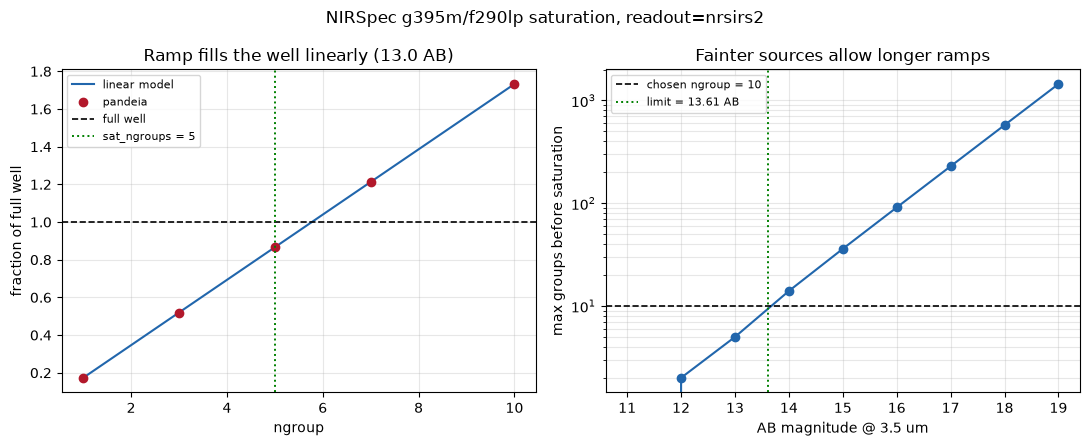

In [5]:
# Panel 1: fraction_saturation grows linearly with ngroup.
# One calculation fixes the slope; a few sampled points confirm it.
per_group = r['frac_sat'] / ngroup # fill fraction per group
ng_axis = np.arange(1, int(r['sat_ngroups']) * 2 + 1)
sampled_ng = np.unique(np.clip(
    np.linspace(1, ng_axis.max(), 5).astype(int), 1, None))
sampled_frac = [saturation_report(magnitude, int(n))['frac_sat'] for n in sampled_ng]

# Panel 2: how the group limit depends on source brightness
mags = np.arange(np.floor(mag_limit) - 2, np.floor(mag_limit) + 7, 1.0)
sat_ng = [saturation_report(m, ngroup)['sat_ngroups'] for m in mags]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(ng_axis, per_group * ng_axis, color='#2166ac', label='linear model')
ax1.plot(sampled_ng, sampled_frac, 'o', color='#b2182b', label='pandeia')
ax1.axhline(1.0, color='k', ls='--', lw=1.2, label='full well')
ax1.axvline(r['sat_ngroups'], color='green', ls=':', lw=1.4,
            label=f"sat_ngroups = {r['sat_ngroups']}")
ax1.set_xlabel('ngroup')
ax1.set_ylabel('fraction of full well')
ax1.set_title(f'Ramp fills the well linearly ({magnitude} AB)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

ax2.plot(mags, sat_ng, 'o-', color='#2166ac')
ax2.axhline(ngroup, color='k', ls='--', lw=1.2, label=f'chosen ngroup = {ngroup}')
ax2.axvline(mag_limit, color='green', ls=':', lw=1.4,
            label=f'limit = {mag_limit:.2f} AB')
ax2.set_yscale('log')
ax2.set_xlabel(f'AB magnitude @ {norm_wave} um')
ax2.set_ylabel('max groups before saturation')
ax2.set_title('Fainter sources allow longer ramps')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, which='both')

fig.suptitle(f'NIRSpec {disperser}/{filter} saturation, readout={readout_pattern}')
fig.tight_layout()
plt.show()